## Домашнее задание №2
Дисциплина Современные методы анализы данных

Тема Темы 1–3: библиотека NumPy, библиотека Pandas, визуализация данных

Выполнила: Полулях Анастасия

### Выбор и описание данных
#### Датасет: 
`penguins.csv`
#### Источник: 
https://www.kaggle.com/datasets/ranaghulamnabi/penguins-dataset-for-visualization-and-m-l?resource=download
#### Описание: 
`В этом наборе данных содержится информация о трех видах пингвинов.В нем указаны размер клюва, длина ласт и вес тела. С его помощью можно увидеть различия между видами и полами.`
#### Столбцы:
`id`	- уникальный ID каждого пингвина (int)

`species`	- вид пингвина (Str)

`island` - остров обитания (Str)

`bill_length_mm` - длина клюва в миллиметрах (Float)

`bill_depth_mm` - глубина клюва в миллиметрах (Float)

`flipper_length_mm` - длина ласт (Float)

`body_mass_g`	- вес пингвина в граммах (Float)

`sex`	- пол (Str)

`year` - год (int)

#### Гипотезы:
1. У пингвинов вида "Adelie" средний вес больше чем у остальных
2. Длина клюва зависит от длины ласт
3. Самцы пингвинов тяжелее самок в 2 раза

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Предобработка данных

In [101]:
dataset = pd.read_csv('penguins.csv')
dataset.head()

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


#### Посмотрим общую информацию о датасете
Видим:
Есть пропущенные значения в столбце sex (пол) по 11 пингвинам
У 2х пингвинов нет записей размеров клюва и крыльев

Тип данных везде правильный.
К названиям столбцов вопросов нет


In [102]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


Проверка пропущенных значений
По пингвинам с айди 3 и 271 все строки с важными параметрами пустые - исключим их и обновим индексы

In [103]:
dataset[dataset['bill_length_mm'].isna()]

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
271,271,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,2009


In [104]:
dataset_filtered= dataset[dataset['bill_length_mm'].notna()].reset_index(drop=True)
dataset_filtered.head()

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [105]:
numeric_vars = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
dataset_filtered[numeric_vars].describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.22,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00


### Оценка категориальных переменных: вид пингвинов, острова проживания, пол

Text(0.5, 1.0, 'Распределение пингвинов по полу')

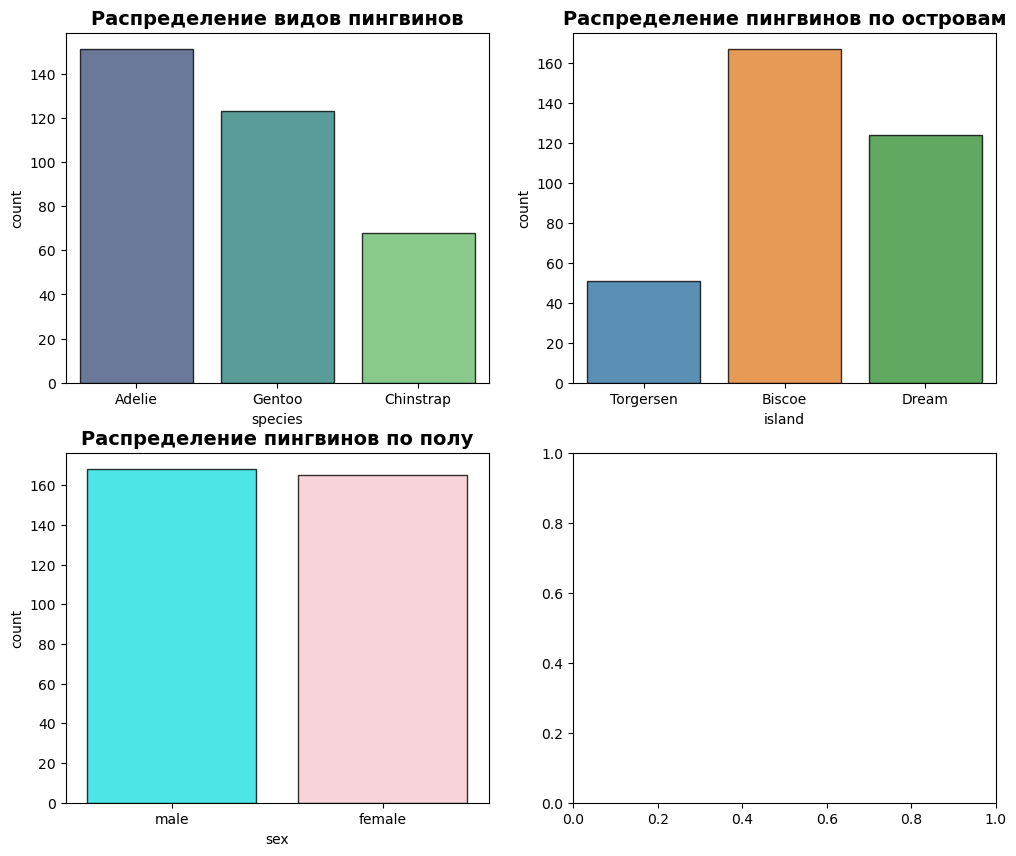

In [106]:
## вывожу барчары для кажой категориальной переменной
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(data=dataset_filtered, 
              x='species', hue='species',
              ax=axes[0,0], 
              palette='viridis', 
              legend=False, 
              edgecolor='black', 
              alpha=0.8)
axes[0,0].set_title('Распределение видов пингвинов', fontsize=14, fontweight='bold')

sns.countplot(data=dataset_filtered, 
              x='island', hue='island',
              ax=axes[0,1], 
              palette='tab10', 
              legend=False,
              edgecolor='black', 
              alpha=0.8)
axes[0,1].set_title('Распределение пингвинов по островам', fontsize=14, fontweight='bold')

## присуждаю по полу стереотипные цвета для упрощения понимания
species_counts = dataset_filtered['species'].value_counts()
species_colors = {
    'male': '#00FFFF',
    'female': '#FFC0CB'}
sns.countplot(data=dataset_filtered, 
              x='sex', hue='sex',
              ax=axes[1,0], 
              palette=species_colors, 
              legend=False,
              edgecolor='black', 
              alpha=0.8)
axes[1,0].set_title('Распределение пингвинов по полу', fontsize=14, fontweight='bold')

Вывод:
Пингвины вида Adelie преобладают и их количество почти в 2 раза больше Chinstrap
Больше всего пингвинов из датафрейма живет на острове Biscoe
В данных равное количество самок и самцов пингвинов

### Оценка количественных переменных: длина клюва, глубина клюва, длина ласт, вес 

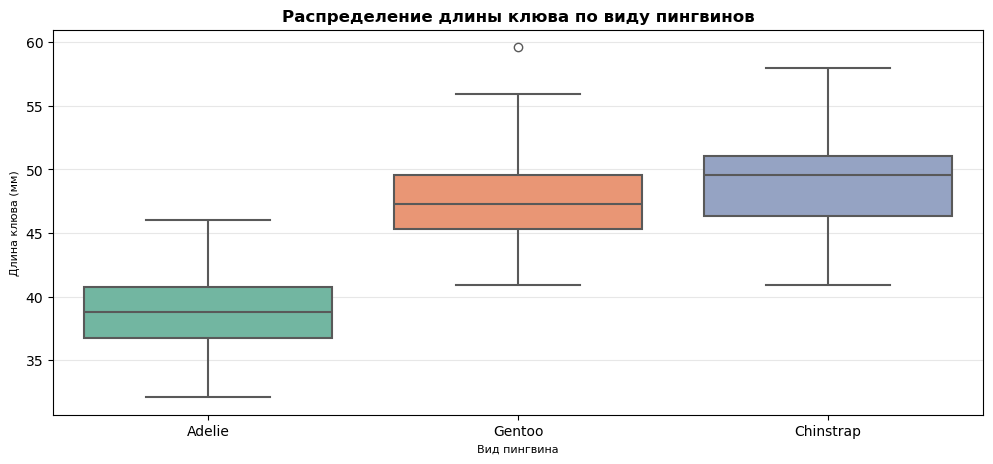

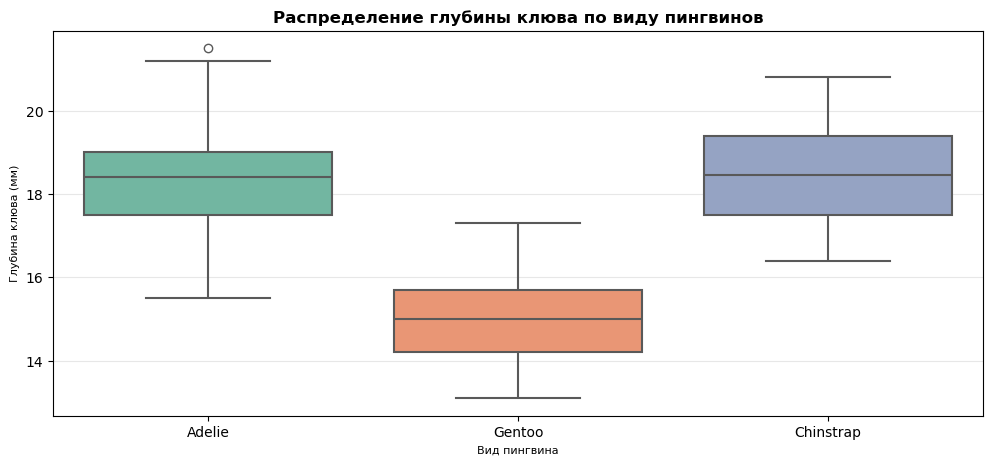

In [107]:
## выбираю грфик "Ящик с усами", так как он наиболее удобен для первичной оценки данных
fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(data=dataset_filtered, x='species', y='bill_length_mm',  #длина клюва в миллиметрах
            hue='species', palette='Set2', legend=False,
            ax=ax, linewidth=1.5, fliersize=6)

ax.set_title('Распределение длины клюва по виду пингвинов', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Вид пингвина', fontsize=8)
ax.set_ylabel('Длина клюва (мм)', fontsize=8)
ax.grid(True, axis='y', alpha=0.3)


fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(data=dataset_filtered, x='species', y='bill_depth_mm',  #глубина клюва в миллиметрах
            hue='species', palette='Set2', legend=False,
            ax=ax, linewidth=1.5, fliersize=6)

ax.set_title('Распределение глубины клюва по виду пингвинов', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Вид пингвина', fontsize=8)
ax.set_ylabel('Глубина клюва (мм)', fontsize=8)
ax.grid(True, axis='y', alpha=0.3)

выбросов и отклоняющихся данных нет

<Axes: >

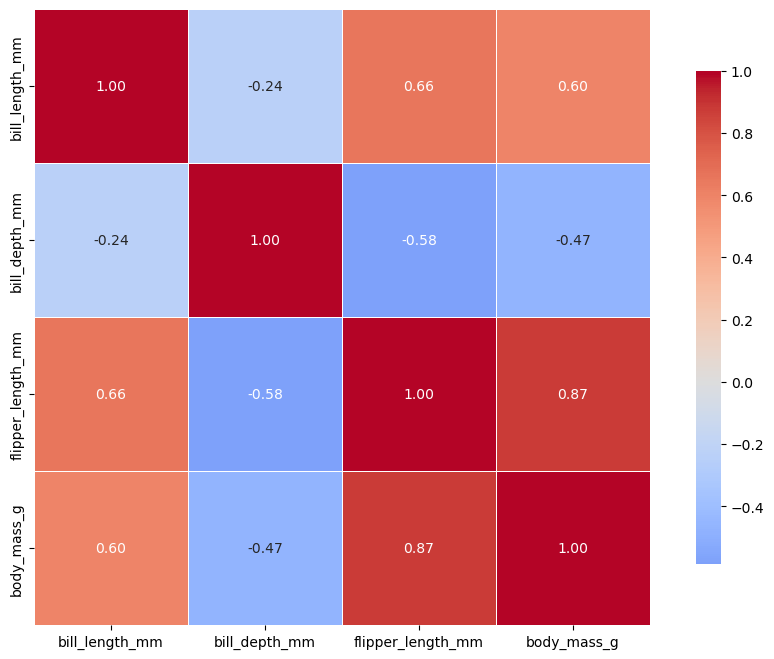

In [108]:
## делаю тепловую карту со значением корреляции, чтобы визуально понять какие данные связаны 
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
numeric_data = dataset_filtered[numeric_cols]

corr_matrix = numeric_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
            annot=True,           
            cmap='coolwarm',     
            center=0,             
            fmt='.2f',            
            square=True,          
            linewidths=0.5,       
            cbar_kws={'shrink': 0.8})  


## Обратим внимание на:

Корреляцию Длины ласт и массу тела

Корреляцию длины клюва и длины ласт

Коэффициент корреляции Пирсона: r = 0.656


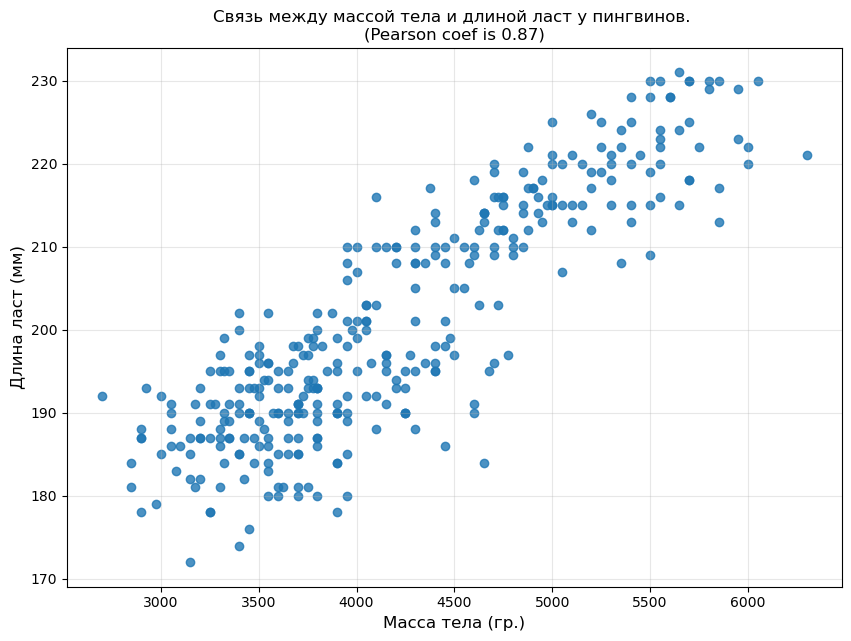

In [109]:
## считаю Коэффициент корреляции Пирсона и построю график рассеяния

pearson_coef = dataset_filtered['body_mass_g'].corr(dataset_filtered['flipper_length_mm'])
print(f"Коэффициент корреляции Пирсона: r = {correlation:.3f}")

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(dataset_filtered['body_mass_g'].values, dataset_filtered['flipper_length_mm'].values, alpha=.8)  # если много точек, лучше ставить alpha поменьше

ax.set_title(f'Связь между массой тела и длиной ласт у пингвинов. \n(Pearson coef is {pearson_coef:.02})')
ax.set_xlabel('Масса тела (гр.)', fontsize=12)
ax.set_ylabel('Длина ласт (мм)', fontsize=12);
ax.grid(True, alpha=0.3)

## Вывод:
Обнаружена сильная положиельная корреляция 0.87. 
Это означает, что пингвины с более длинными ластами, как правило, имеют больший вес. 
Такая связь ожидаема.

Коэффициент корреляции Пирсона: r = 0.656


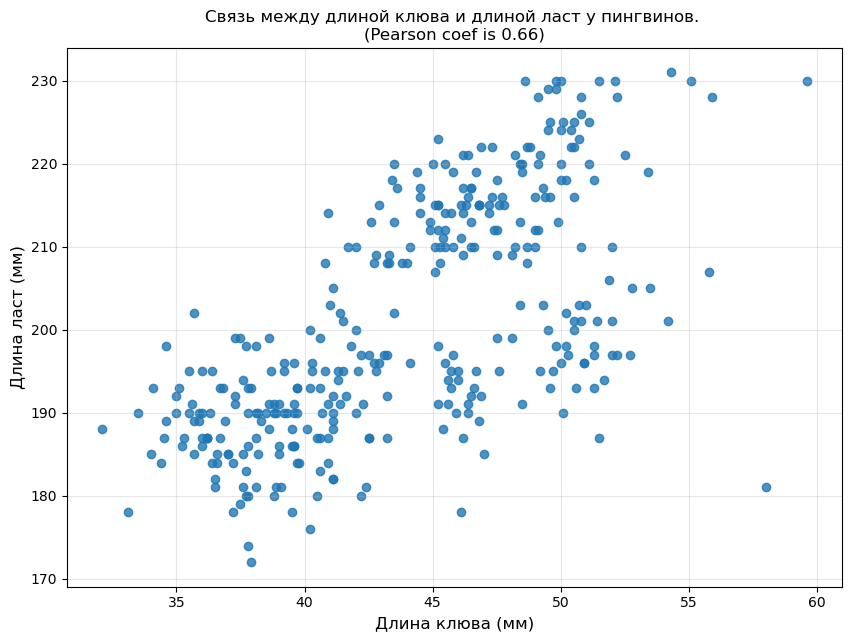

In [110]:
## считаю Коэффициент корреляции Пирсона и построю график рассеяния

pearson_coef = dataset_filtered['bill_length_mm'].corr(dataset_filtered['flipper_length_mm'])
print(f"Коэффициент корреляции Пирсона: r = {correlation:.3f}")

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(dataset_filtered['bill_length_mm'].values, dataset_filtered['flipper_length_mm'].values, alpha=.8)  # если много точек, лучше ставить alpha поменьше

ax.set_title(f'Связь между длиной клюва и длиной ласт у пингвинов. \n(Pearson coef is {pearson_coef:.02})')
ax.set_xlabel('Длина клюва (мм)', fontsize=12)
ax.set_ylabel('Длина ласт (мм)', fontsize=12);
ax.grid(True, alpha=0.3)

## Вывод:
Обнаружена умеренная положиельная корреляция 0.66. 
Это означает, что пингвины с более длинным клювом, как правило, имеют и более длинные ласты. Такая связь может объясняться пропорциональностью - более крупные особи имеют большие пропорции всех частей тела.

#### Распределение массы тела по видам 

               Среднее  Медиана  Станд. отклонение  Количество
species                                                       
Adelie     3700.662252   3700.0         458.566126         151
Chinstrap  3733.088235   3700.0         384.335081          68
Gentoo     5076.016260   5000.0         504.116237         123


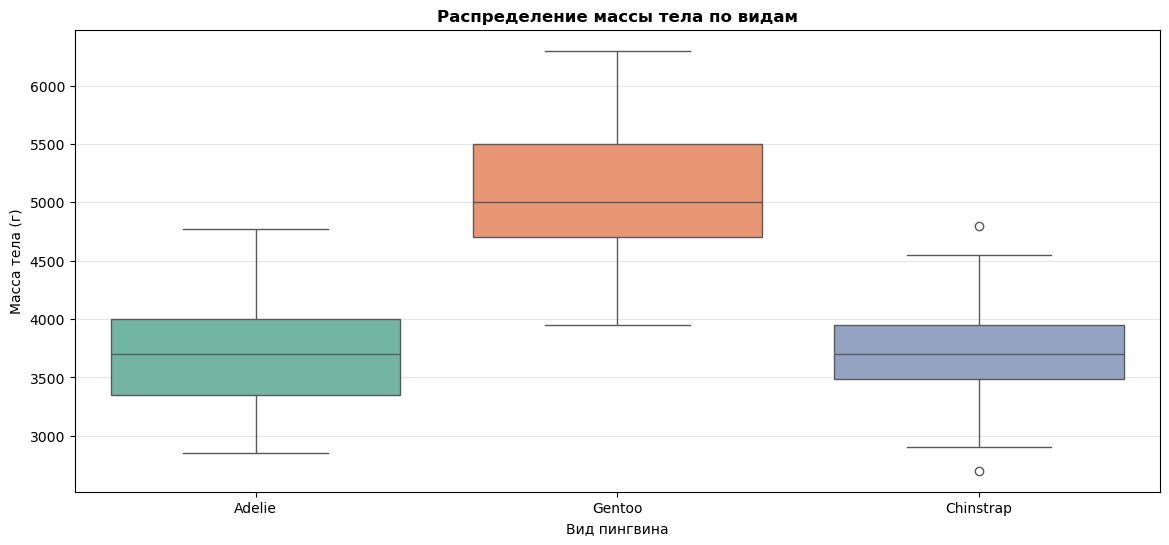

In [111]:
## строим ящик с усами и таблицу с основными метриками для понимания данных
species_stats = dataset_filtered.groupby('species')['body_mass_g'].agg(['mean', 'median', 'std', 'count'])
species_stats.columns = ['Среднее', 'Медиана', 'Станд. отклонение', 'Количество']
print(species_stats)
fig, axes = plt.subplots(1, figsize=(14, 6))

sns.boxplot(data=dataset_filtered, x='species', y='body_mass_g', 
            hue='species', palette='Set2', legend=False, ax=axes)
axes.set_title('Распределение массы тела по видам', fontsize=12, fontweight='bold')
axes.set_xlabel('Вид пингвина')
axes.set_ylabel('Масса тела (г)')
axes.grid(True, axis='y', alpha=0.3)

## Вывод:
Масса тела действительно сильно зависит от вида пингивна. Наиболее крупными явяются пингвины вида "Getnoo" ~5000 г.

            Среднее  Медиана  Станд. отклонение  Количество
sex                                                        
female  3862.272727   3650.0         666.172050         165
male    4545.684524   4300.0         787.628884         168


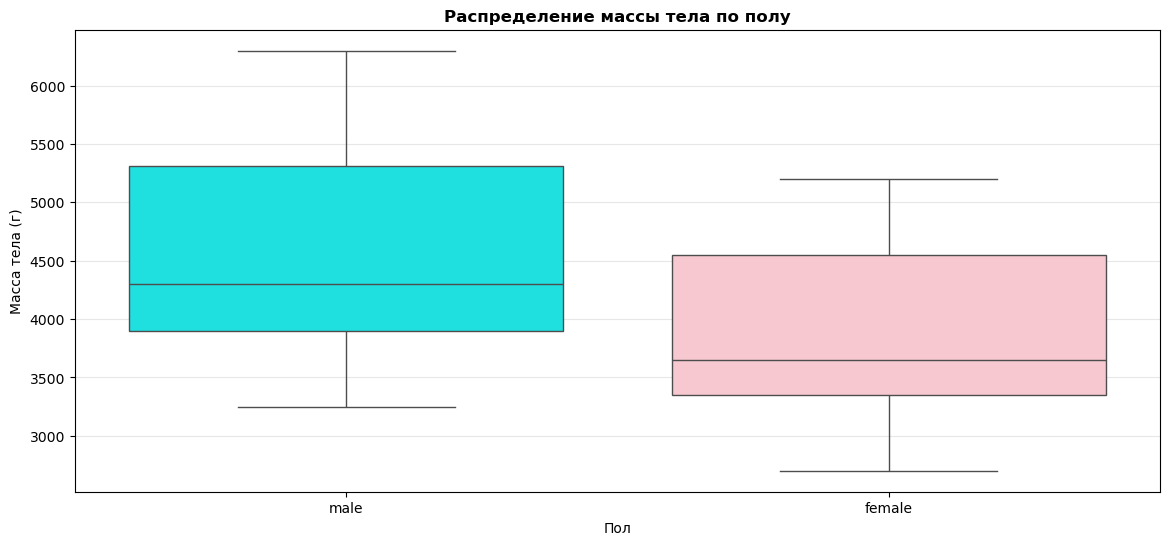

In [112]:
species_stats = dataset_filtered.groupby('sex')['body_mass_g'].agg(['mean', 'median', 'std', 'count'])
species_stats.columns = ['Среднее', 'Медиана', 'Станд. отклонение', 'Количество']
print(species_stats)
fig, axes = plt.subplots(1, figsize=(14, 6))
species_colors = {
    'male': '#00FFFF',
    'female': '#FFC0CB'}

sns.boxplot(data=dataset_filtered, x='sex', y='body_mass_g', 
            hue='sex', palette=species_colors, legend=False, ax=axes)
axes.set_title('Распределение массы тела по полу', fontsize=12, fontweight='bold')
axes.set_xlabel('Пол')
axes.set_ylabel('Масса тела (г)')
axes.grid(True, axis='y', alpha=0.3)


## Вывод:
Масса тела действительно сильно зависит от пола пингивна. В среднем самцы почти на 700 г. тяжелее самок

### Merge к таблице с характеристиками пингвина


In [113]:
## готовую таблицу не нашла, пришлость делать самостоятельно

penguin_descriptions = pd.DataFrame({
    'species': ['Adelie', 'Chinstrap', 'Gentoo'],
    
    'distinctive_markings': [
        'Белые кольца вокруг глаз, красновато-черный клюв, розовые лапы',
        'Черная полоса-ремень под подбородком, черный клюв, белое лицо', 
        'Белая полоса через макушку (белобровый), оранжево-красный клюв'
    ],
    'head_color': ['Черная с белыми кольцами', 'Черная шапочка, белое лицо', 'Черная с белыми очками'],
    
    # Анатомические особенности
    'has_external_ears': [False, False, False],  # у всех пингвинов нет внешних ушей
    'ear_description': [
        'Отверстия, покрытые перьями; отличный слух для распознавания голосов',
        'Отверстия, покрытые перьями; узнают пару и птенцов по голосу',
        'Отверстия, покрытые перьями; могут слышать под водой на глубине'
    ],
    'special_hearing': [
        'Распознают 1.5 млн пингвинов в колонии по голосу',
        'Спят микро-снами до 4 секунд, всего 11 часов в день',
        'Имеют сложную систему слуха для подводной охоты'],
    })
penguin_descriptions.head()

,species,distinctive_markings,head_color,has_external_ears,ear_description,special_hearing
0,Adelie,"Белые кольца вокруг глаз, красновато-черный кл...",Черная с белыми кольцами,False,"Отверстия, покрытые перьями; отличный слух для...",Распознают 1.5 млн пингвинов в колонии по голосу
1,Chinstrap,"Черная полоса-ремень под подбородком, черный к...","Черная шапочка, белое лицо",False,"Отверстия, покрытые перьями; узнают пару и пте...","Спят микро-снами до 4 секунд, всего 11 часов в..."
2,Gentoo,"Белая полоса через макушку (белобровый), оранж...",Черная с белыми очками,False,"Отверстия, покрытые перьями; могут слышать под...",Имеют сложную систему слуха для подводной охоты


In [114]:
joined = dataset_filtered.merge(penguin_descriptions, on = 'species', how = 'left')
joined.head()

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,distinctive_markings,head_color,has_external_ears,ear_description,special_hearing
0,0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,"Белые кольца вокруг глаз, красновато-черный кл...",Черная с белыми кольцами,False,"Отверстия, покрытые перьями; отличный слух для...",Распознают 1.5 млн пингвинов в колонии по голосу
1,1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,"Белые кольца вокруг глаз, красновато-черный кл...",Черная с белыми кольцами,False,"Отверстия, покрытые перьями; отличный слух для...",Распознают 1.5 млн пингвинов в колонии по голосу
2,2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,"Белые кольца вокруг глаз, красновато-черный кл...",Черная с белыми кольцами,False,"Отверстия, покрытые перьями; отличный слух для...",Распознают 1.5 млн пингвинов в колонии по голосу
3,4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,"Белые кольца вокруг глаз, красновато-черный кл...",Черная с белыми кольцами,False,"Отверстия, покрытые перьями; отличный слух для...",Распознают 1.5 млн пингвинов в колонии по голосу
4,5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,"Белые кольца вокруг глаз, красновато-черный кл...",Черная с белыми кольцами,False,"Отверстия, покрытые перьями; отличный слух для...",Распознают 1.5 млн пингвинов в колонии по голосу


Text(0.5, 1.0, 'Распределение пингвинов по окрасу головы')

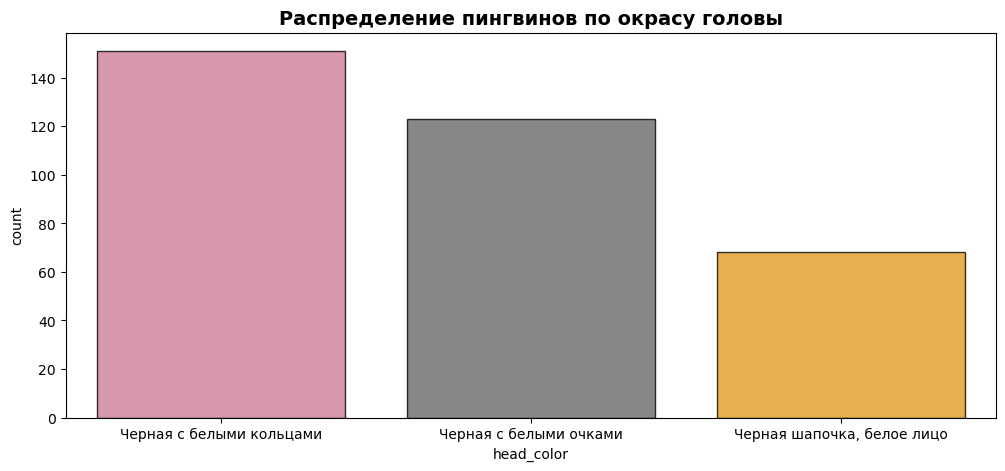

In [115]:
## визуализация данных из присоединенной таблицы
fig, ax = plt.subplots(figsize=(12, 5))

species_colors = {
    'Черная с белыми кольцами': '#DB7093',
    'Черная шапочка, белое лицо': '#FFA500',
    'Черная с белыми очками': '#696969'}

sns.countplot(data=joined, 
              x='head_color', hue='head_color',
              palette=species_colors, 
              legend=False,
              edgecolor='black', 
              alpha=0.8)
ax.set_title('Распределение пингвинов по окрасу головы', fontsize=14, fontweight='bold')

### Итого:
У пингвинов вида "Adelie" средний вес больше чем у остальных - гипотеза неверная, наибольший средний вес у пингвинов "Getnoo" ~5000 г.
Длина клюва зависит от длины ласт - корреляция наблюдается, она объяняется пропорциональзностью тела пингвина
Самцы пингвинов тяжелее самок в 2 раза - самцы действительно тяжелее самок, но не в 2 раза, на 17,7%